# Temperature Ablation：T = 5

**相似度差一點沒那麼重要**  
SimCLR → Temperature = 0.5 → 訓練 → Loss / kNN Accuracy → 作為比較基準

## step1:Import + 基本設定

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18

import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## step2:CIFAR-10 + SimCLR Augmentation

In [4]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

class SimCLRTransform:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(32, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([
                transforms.ColorJitter(
                    brightness=0.4,
                    contrast=0.4,
                    saturation=0.4,
                    hue=0.1
                )
            ], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
        ])

    def __call__(self, image):
        return self.transform(image), self.transform(image)


train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=SimCLRTransform()
)

batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

print("Train:", len(train_dataset))

c:\Users\user\anaconda3\envs\summer\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 50000


## step3:kNN Evaluation Dataset

In [5]:
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

knn_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=eval_transform
)

knn_test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=eval_transform
)

knn_train_loader = DataLoader(
    knn_train_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

knn_test_loader = DataLoader(
    knn_test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

print("kNN train:", len(knn_train_dataset))
print("kNN test:", len(knn_test_dataset))

kNN train: 50000
kNN test: 10000


## step4:SimCLR Model

In [6]:
class SimCLRModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = resnet18(weights=None)

        self.backbone.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.backbone.maxpool = nn.Identity()
        self.backbone.fc = nn.Identity()

        self.projector = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward(self, x):
        h = self.backbone(x)
        z = self.projector(h)
        return h, z

## step5:NT-Xent Loss

In [7]:
def nt_xent_loss(z1, z2, temperature=0.1):
    N = z1.size(0)

    z = torch.cat([z1, z2], dim=0)
    z = F.normalize(z, dim=1)

    similarity = torch.matmul(z, z.T) / temperature

    mask = torch.eye(
        2 * N,
        dtype=torch.bool,
        device=z.device
    )

    similarity.masked_fill_(mask, -float("inf"))

    labels = torch.arange(2 * N, device=z.device)
    labels = (labels + N) % (2 * N)

    loss = F.cross_entropy(similarity, labels)

    return loss

## step6:kNN Monitor

In [8]:
@torch.no_grad()
def knn_monitor(model, train_loader, test_loader, device, k=20):
    model.eval()

    feature_bank = []
    label_bank = []

    for images, labels in train_loader:
        images = images.to(device)

        h, _ = model(images)
        h = F.normalize(h, dim=1)

        feature_bank.append(h)
        label_bank.append(labels)

    feature_bank = torch.cat(feature_bank, dim=0)
    label_bank = torch.cat(label_bank, dim=0).to(device)

    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        h, _ = model(images)
        h = F.normalize(h, dim=1)

        similarity = torch.mm(h, feature_bank.T)

        _, indices = similarity.topk(k=k, dim=1)
        neighbor_labels = label_bank[indices]

        predictions = torch.mode(
            neighbor_labels,
            dim=1
        ).values

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    accuracy = 100.0 * correct / total

    model.train()

    return accuracy

## step7:正式訓練 T = 5

In [11]:
num_epochs = 200

temperature = 5
learning_rate = 3e-4
weight_decay = 1e-6

knn_interval = 5
k = 20

model = SimCLRModel().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

loss_history = []
knn_epochs = []
knn_history = []

training_start = time.time()

for epoch in range(1, num_epochs + 1):

    model.train()

    total_loss = 0.0
    epoch_start = time.time()

    for (x1, x2), _ in train_loader:

        x1 = x1.to(device)
        x2 = x2.to(device)

        optimizer.zero_grad()

        _, z1 = model(x1)
        _, z2 = model(x2)

        loss = nt_xent_loss(
            z1,
            z2,
            temperature=temperature
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch:3d}/{num_epochs}] "
        f"| Loss: {avg_loss:.4f} "
        f"| Time: {epoch_time:.1f}s",
        end=""
    )

    if epoch % knn_interval == 0:

        knn_start = time.time()

        knn_acc = knn_monitor(
            model,
            knn_train_loader,
            knn_test_loader,
            device,
            k=k
        )

        knn_time = time.time() - knn_start

        knn_epochs.append(epoch)
        knn_history.append(knn_acc)

        print(
            f" | kNN Accuracy: {knn_acc:.2f}% "
            f"| kNN Time: {knn_time:.1f}s"
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss_history": loss_history,
                "knn_epochs": knn_epochs,
                "knn_history": knn_history,
                "temperature": temperature
            },
            "simclr_temp05_checkpoint.pth"
        )

    else:
        print()

torch.save(
    model.state_dict(),
    "simclr_temp5_final.pth"
)

total_time = time.time() - training_start

print("\n===== Temperature 5 Finished =====")
print(f"Total Training Time: {total_time / 3600:.2f} hours")
print(f"Final Loss: {loss_history[-1]:.4f}")
print(f"Final kNN Accuracy: {knn_history[-1]:.2f}%")

Epoch [  1/200] | Loss: 6.1147 | Time: 73.2s
Epoch [  2/200] | Loss: 6.0977 | Time: 72.9s
Epoch [  3/200] | Loss: 6.0900 | Time: 72.7s
Epoch [  4/200] | Loss: 6.0845 | Time: 78.0s
Epoch [  5/200] | Loss: 6.0803 | Time: 83.7s | kNN Accuracy: 44.85% | kNN Time: 9.8s
Epoch [  6/200] | Loss: 6.0771 | Time: 83.0s
Epoch [  7/200] | Loss: 6.0752 | Time: 84.3s
Epoch [  8/200] | Loss: 6.0741 | Time: 84.8s
Epoch [  9/200] | Loss: 6.0725 | Time: 83.9s
Epoch [ 10/200] | Loss: 6.0716 | Time: 82.2s | kNN Accuracy: 50.06% | kNN Time: 9.6s
Epoch [ 11/200] | Loss: 6.0704 | Time: 82.8s
Epoch [ 12/200] | Loss: 6.0694 | Time: 82.7s
Epoch [ 13/200] | Loss: 6.0693 | Time: 84.5s
Epoch [ 14/200] | Loss: 6.0684 | Time: 81.7s
Epoch [ 15/200] | Loss: 6.0676 | Time: 83.4s | kNN Accuracy: 53.55% | kNN Time: 9.7s
Epoch [ 16/200] | Loss: 6.0669 | Time: 83.7s
Epoch [ 17/200] | Loss: 6.0665 | Time: 82.7s
Epoch [ 18/200] | Loss: 6.0659 | Time: 83.9s
Epoch [ 19/200] | Loss: 6.0656 | Time: 82.1s
Epoch [ 20/200] | Loss: 6

## step8:畫圖

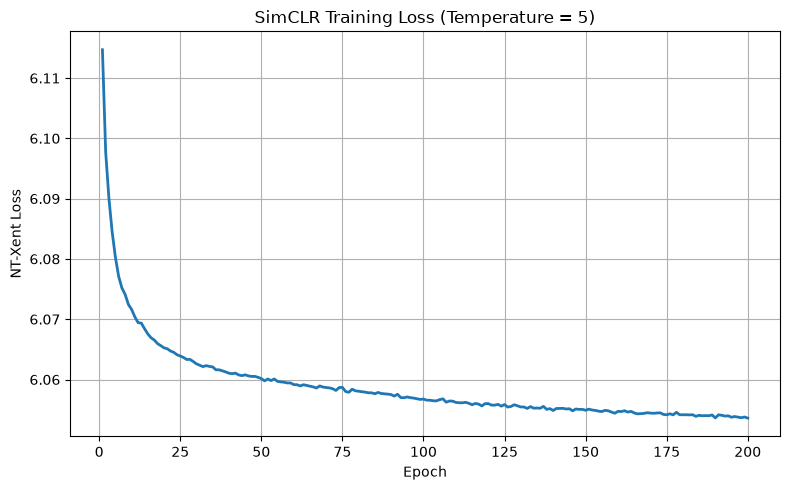

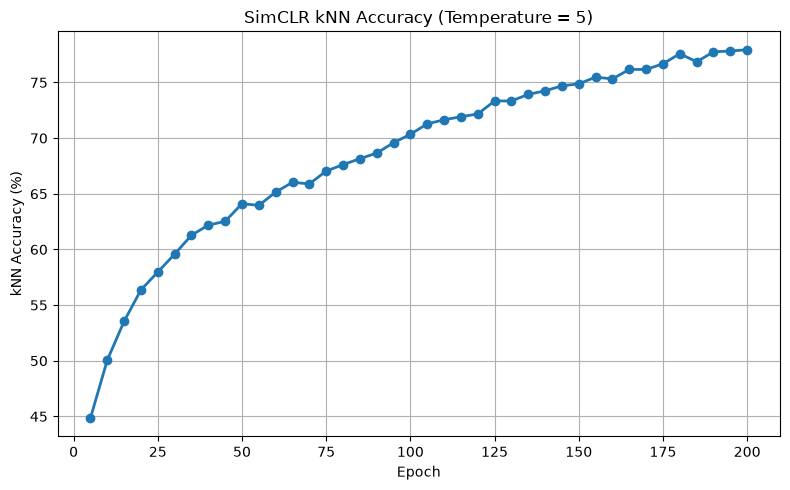

In [12]:
# Loss Curve
epochs = range(1, len(loss_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_history, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.title("SimCLR Training Loss (Temperature = 5)")
plt.grid(True)

plt.tight_layout()
plt.savefig("simclr_temp5_loss_curve.png", dpi=300)
plt.show()


# kNN Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(
    knn_epochs,
    knn_history,
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("kNN Accuracy (%)")
plt.title("SimCLR kNN Accuracy (Temperature = 5)")
plt.grid(True)

plt.tight_layout()
plt.savefig("simclr_temp5_knn_curve.png", dpi=300)
plt.show()